In [ ]:
from google.colab import files
import pandas as pd

# Upload file from laptop
uploaded = files.upload()

# Read the uploaded Excel file
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

# Display first 5 rows
df.head()

Saving jackfruit.xlsx to jackfruit (1).xlsx


,Folder,Filename,Label,PeakFreq_Hz,SpectralCentroid_Hz,SpectralBandwidth_Hz,SpectralRolloff_Hz,SpectralFlatness,SpectralEntropy,Skewness,...,MFCC_4,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13
0,Immature fruit,P 1.1.mp3,Immature,175.78125,215.005329,270.131370,246.09375,0.000069,3.024281,15.765118,...,5.766250,2.224167,2.047610,-1.835847,-0.222456,0.265040,-0.148960,0.298026,-2.707732,-0.754664
1,Immature fruit,P 1.2.mp3,Immature,175.78125,235.916122,401.805272,187.50000,0.000064,2.585966,9.299207,...,6.429102,1.711817,1.336669,-2.891185,2.926954,1.709397,-2.001837,-0.196131,-0.505389,-0.416713
2,Immature fruit,P 1.3.mp3,Immature,187.50000,240.604090,332.250564,246.09375,0.000433,3.398424,14.531308,...,5.393660,1.359017,0.948619,-1.313583,1.485382,1.245911,-1.892102,-1.041187,-1.828770,-0.394867
3,Immature fruit,P 1.4.mp3,Immature,187.50000,256.592278,443.473200,246.09375,0.000013,3.384758,7.859858,...,7.433111,1.447809,-0.433645,0.616672,2.720343,-0.300411,-1.219538,-2.392897,0.046949,-0.877949
4,Immature fruit,P 2.1.mp3,Immature,234.37500,216.956128,233.172327,246.09375,0.000012,3.181795,14.267315,...,7.394655,1.268484,0.898059,0.931308,0.840227,-1.289834,-1.508534,-1.555398,-0.160719,-0.705120


#libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

#Check Dataset

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nClass Distribution:")
print(df['Label'].value_counts())

Shape: (253, 30)

Columns:
Index(['Folder', 'Filename', 'Label', 'PeakFreq_Hz', 'SpectralCentroid_Hz',
       'SpectralBandwidth_Hz', 'SpectralRolloff_Hz', 'SpectralFlatness',
       'SpectralEntropy', 'Skewness', 'Kurtosis', 'HNR_dB', 'BE_50_200',
       'BE_200_500', 'BE_500_1500', 'BE_1500_4000', 'BE_4000_8000', 'MFCC_1',
       'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7', 'MFCC_8',
       'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13'],
      dtype='object')

Class Distribution:
Label
Mature      184
Immature     69
Name: count, dtype: int64


#Separate Features and Label

In [ ]:
X = df.drop(['Folder','Filename','Label'], axis=1)

y = df['Label']

print(X.shape)
print(y.shape)

(253, 27)
(253,)


#Train and split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Feature scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#svm

In [ ]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.8823529411764706


In [ ]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

    Immature       0.83      0.71      0.77        14
      Mature       0.90      0.95      0.92        37

    accuracy                           0.88        51
   macro avg       0.87      0.83      0.85        51
weighted avg       0.88      0.88      0.88        51



#KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.803921568627451


In [ ]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

    Immature       0.70      0.50      0.58        14
      Mature       0.83      0.92      0.87        37

    accuracy                           0.80        51
   macro avg       0.76      0.71      0.73        51
weighted avg       0.79      0.80      0.79        51



#Catboost

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=0
)

cat_model.fit(X_train, y_train)

cat_pred = cat_model.predict(X_test)

print("CatBoost Accuracy:", accuracy_score(y_test, cat_pred))

CatBoost Accuracy: 0.9215686274509803


In [ ]:
print(classification_report(y_test, cat_pred))

              precision    recall  f1-score   support

    Immature       0.92      0.79      0.85        14
      Mature       0.92      0.97      0.95        37

    accuracy                           0.92        51
   macro avg       0.92      0.88      0.90        51
weighted avg       0.92      0.92      0.92        51



LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, lgbm_pred))

LightGBM Accuracy: 0.9019607843137255


In [ ]:
print(classification_report(y_test, lgbm_pred))

              precision    recall  f1-score   support

    Immature       0.80      0.86      0.83        14
      Mature       0.94      0.92      0.93        37

    accuracy                           0.90        51
   macro avg       0.87      0.89      0.88        51
weighted avg       0.90      0.90      0.90        51



#Comparision Table

In [ ]:
results = pd.DataFrame({
    'Model':['SVM','KNN','CatBoost','LightGBM'],
    'Accuracy':[
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, cat_pred),
        accuracy_score(y_test, lgbm_pred)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,CatBoost,0.921569
3,LightGBM,0.901961
0,SVM,0.882353
1,KNN,0.803922


#Accuracy Comparison Graph

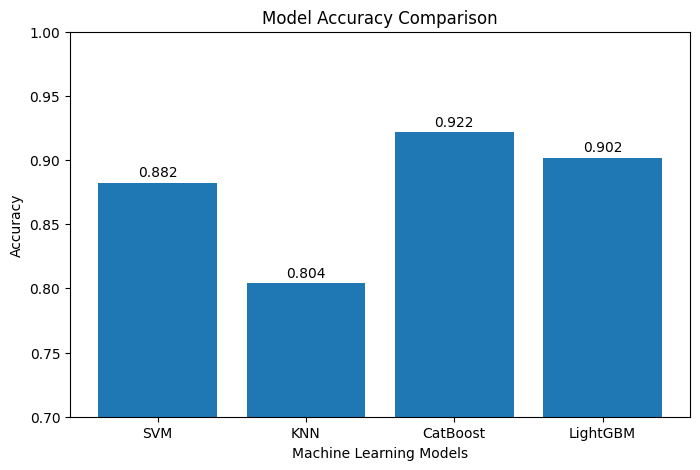

In [ ]:
import matplotlib.pyplot as plt

models = ['SVM', 'KNN', 'CatBoost', 'LightGBM']
accuracies = [0.882353, 0.803922, 0.921569, 0.901961]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy')

plt.ylim(0.7,1.0)

for i, acc in enumerate(accuracies):
    plt.text(i, acc+0.005, f'{acc:.3f}', ha='center')

plt.show()

#CatBoost hyperparameter tuning

In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

params = {
    'depth': [4,6,8],
    'learning_rate': [0.01,0.05,0.1],
    'iterations': [100,200,300]
}

random_search = RandomizedSearchCV(
    CatBoostClassifier(verbose=0),
    params,
    n_iter=10,      # only 10 combinations
    cv=3,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'learning_rate': 0.01, 'iterations': 300, 'depth': 8}
Best Score: 0.8267486098917178


In [ ]:
best_cat = random_search.best_estimator_

tuned_pred = best_cat.predict(X_test)

from sklearn.metrics import accuracy_score

print("Tuned CatBoost Accuracy:",
      accuracy_score(y_test, tuned_pred))

Tuned CatBoost Accuracy: 0.9019607843137255


## Feature Importance Analysis Using CatBoost

In [ ]:
import pandas as pd

feature_importance = cat_model.get_feature_importance()

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
9,BE_50_200,8.239425
14,MFCC_1,7.898551
16,MFCC_3,7.745463
17,MFCC_4,7.077419
0,PeakFreq_Hz,6.092858
19,MFCC_6,5.523314
20,MFCC_7,4.950165
26,MFCC_13,4.576158
21,MFCC_8,3.941951
12,BE_1500_4000,3.830111


## Feature Importance Analysis Using CatBoost

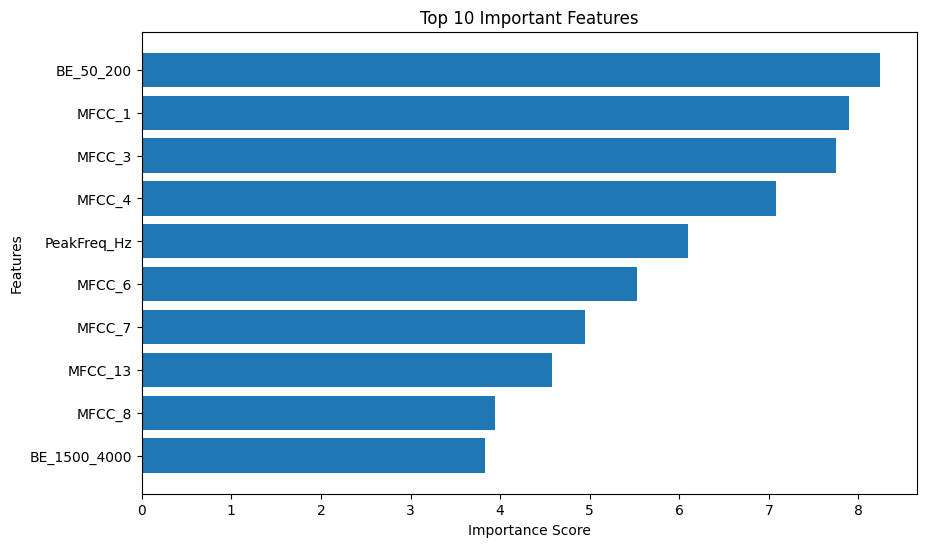

In [ ]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])

plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.gca().invert_yaxis()

plt.show()

## Feature Selection Based Classification

In [ ]:
top_features = [
    'BE_50_200',
    'MFCC_1',
    'MFCC_3',
    'MFCC_4',
    'PeakFreq_Hz',
    'MFCC_6',
    'MFCC_7',
    'MFCC_13',
    'MFCC_8',
    'BE_1500_4000'
]

X_selected = X[top_features]

#Train and split based on selected features

In [ ]:
from sklearn.model_selection import train_test_split

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Train CatBoost on Selected Feature

In [ ]:
from catboost import CatBoostClassifier

cat_fs = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    verbose=0
)

cat_fs.fit(X_train_fs, y_train_fs)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, verbose=0)

#Prediction and Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

fs_pred = cat_fs.predict(X_test_fs)

fs_accuracy = accuracy_score(y_test_fs, fs_pred)

print("Feature Selected CatBoost Accuracy:", fs_accuracy)

Feature Selected CatBoost Accuracy: 0.8823529411764706


#Compare Full Features vs Selected Features

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'CatBoost (27 Features)',
        'CatBoost (Top 10 Features)'
    ],
    'Accuracy': [
        0.921569,   # your original CatBoost result
        fs_accuracy
    ]
})

comparison

,Model,Accuracy
0,CatBoost (27 Features),0.921569
1,CatBoost (Top 10 Features),0.882353


#Comparison Graph

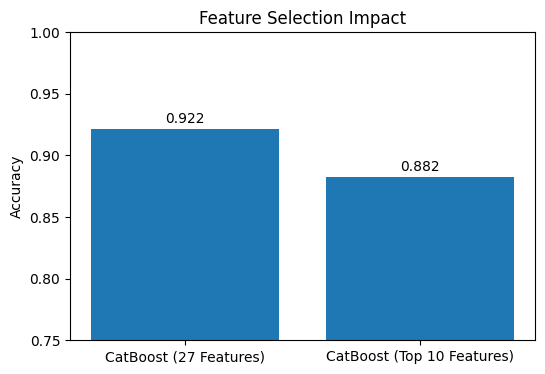

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title('Feature Selection Impact')
plt.ylabel('Accuracy')

for i, v in enumerate(comparison['Accuracy']):
    plt.text(i, v+0.005, f'{v:.3f}', ha='center')

plt.ylim(0.75, 1.0)

plt.show()

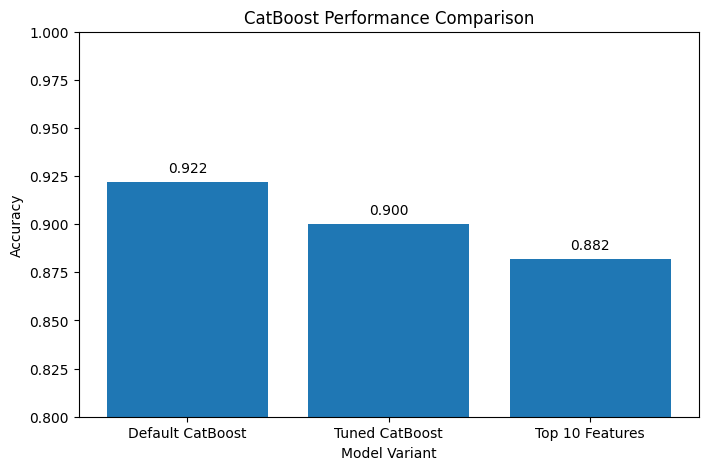

In [ ]:
import matplotlib.pyplot as plt

models = [
    'Default CatBoost',
    'Tuned CatBoost',
    'Top 10 Features'
]

accuracies = [
    0.922,
    0.900,
    0.882
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title('CatBoost Performance Comparison')
plt.xlabel('Model Variant')
plt.ylabel('Accuracy')

for i, acc in enumerate(accuracies):
    plt.text(i, acc+0.005, f'{acc:.3f}', ha='center')

plt.ylim(0.80, 1.00)

plt.show()

### Observation

The default CatBoost model achieved the highest accuracy of 92.16%.
Hyperparameter tuning resulted in a slight decrease in accuracy to approximately 90%.
Similarly, training the model using only the top 10 important features reduced the accuracy to 88.24%.

These results indicate that the default CatBoost configuration with the complete set of 27 acoustic features provides the best classification performance for the given jackfruit maturity dataset.

## Key Findings

- Four machine learning algorithms (SVM, KNN, LightGBM, and CatBoost) were implemented and evaluated for jackfruit maturity classification.
- CatBoost achieved the highest accuracy of 92.16%, making it the best-performing model.
- LightGBM achieved an accuracy of 90.20%, followed by SVM with 88.24%.
- KNN produced the lowest accuracy of 80.39%.
- Hyperparameter tuning was performed on CatBoost, but it did not improve the model performance beyond the default configuration.
- Feature importance analysis identified BE_50_200, MFCC_1, MFCC_3, MFCC_4, PeakFreq_Hz, and other MFCC features as the most influential acoustic features.
- A feature-selection-based model using the top 10 features achieved 88.24% accuracy.
- The full set of 27 acoustic features provided better classification performance than the reduced feature set.

## Conclusion

This study investigated the use of machine learning techniques for jackfruit maturity classification using acoustic features extracted from tapping sound recordings. Multiple classification algorithms, including SVM, KNN, LightGBM, and CatBoost, were developed and compared.

Among the evaluated models, CatBoost achieved the highest classification accuracy of 92.16%, demonstrating superior performance in handling acoustic feature data. Feature importance analysis revealed that Band Energy, MFCC, and Peak Frequency features play a significant role in distinguishing mature and immature jackfruits.

The feature-selection experiment showed that reducing the feature set to the top 10 important features resulted in lower accuracy, indicating that the complete set of extracted acoustic features contributes to improved classification performance.

Overall, the results confirm that acoustic signal analysis combined with machine learning provides an effective and non-destructive approach for jackfruit maturity classification, with CatBoost identified as the most suitable model for this dataset.

## Statistical Analysis of CatBoost

In [ ]:
from sklearn.model_selection import cross_val_score
from catboost import CatBoostClassifier
import numpy as np

model = CatBoostClassifier(verbose=0)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Fold Accuracies:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Variance:", np.var(scores))
print("Standard Deviation:", np.std(scores))

Fold Accuracies: [0.80392157 0.78431373 0.80392157 0.86       0.8       ]
Mean Accuracy: 0.8104313725490198
Variance: 0.0006665497885428676
Standard Deviation: 0.02581762554037198


## Classification Report of CatBoost

In [ ]:
from sklearn.metrics import classification_report

cat_pred = cat_model.predict(X_test)

print(classification_report(y_test, cat_pred))

              precision    recall  f1-score   support

    Immature       0.92      0.79      0.85        14
      Mature       0.92      0.97      0.95        37

    accuracy                           0.92        51
   macro avg       0.92      0.88      0.90        51
weighted avg       0.92      0.92      0.92        51



## Confusion Matrix of CatBoost

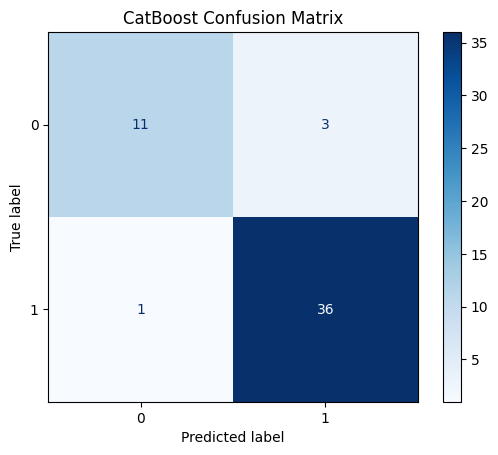

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, cat_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')
plt.title('CatBoost Confusion Matrix')
plt.show()